In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 加载数据
# 假设你的文件包含 'ms', 'd0', 'd1', 'd2', 'd3' 这几列
# 直接加载 Excel 文件，因为 '/content/2_gps_with_minute_time.xlsx' 是 Excel 文件
df = pd.read_excel('/content/2_gps_with_minute_time.xlsx')

# 2. 设置绘图风格
plt.figure(figsize=(300, 6), facecolor='white')

# 3. 绘制四条曲线
# 使用不同的颜色和标签，并将d0, d1, d2, d3的值变为负数以显示在第四象限
plt.plot(df['ms'], -df['d0'], color='#004B8D', linewidth=1.5, label='t0_front') # 更改标签
plt.plot(df['ms'], -df['d1'], color='#B22222', linewidth=1.5, label='t1_left')  # 更改标签
plt.plot(df['ms'], -df['d2'], color='#D4AF37', linewidth=1.5, label='t2_back')  # 更改标签
plt.plot(df['ms'], -df['d3'], color='#2E8B57', linewidth=1.5, label='t3_right') # 更改标签

# 4. 细节调整（模仿原图的极简感）
ax = plt.gca()

# 设置标签
plt.xlabel('Time (ms)', fontsize=10, color='#333333')
plt.ylabel('Value (Negative)', fontsize=10, color='#333333') # 更新Y轴标签

# 隐藏上方和右侧边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# 添加淡灰色水平网格线
plt.grid(axis='y', linestyle='-', alpha=0.3)

# 添加图例
plt.legend(frameon=False, loc='upper right')

# 5. 显示图表
plt.tight_layout()
plt.savefig('plot2.svg', format='svg') # 导出为SVG文件
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import pandas as pd
import os

df = pd.read_csv("/content/1_gps.csv") # 修正了文件名，去掉了多余的'.csv'

# 保留每隔两行的数据（即保留第1行，然后每隔2行保留一行）
df_new = df.iloc[::3]

# 定义目标文件夹路径
output_directory = "/content/drive/MyDrive/Semester_2/Dataform_delete/deleted"

# 检查并创建目标文件夹（如果不存在）
os.makedirs(output_directory, exist_ok=True)

# 保存文件
df_new.to_csv(os.path.join(output_directory, "/content/1_gps.csv"), index=False)

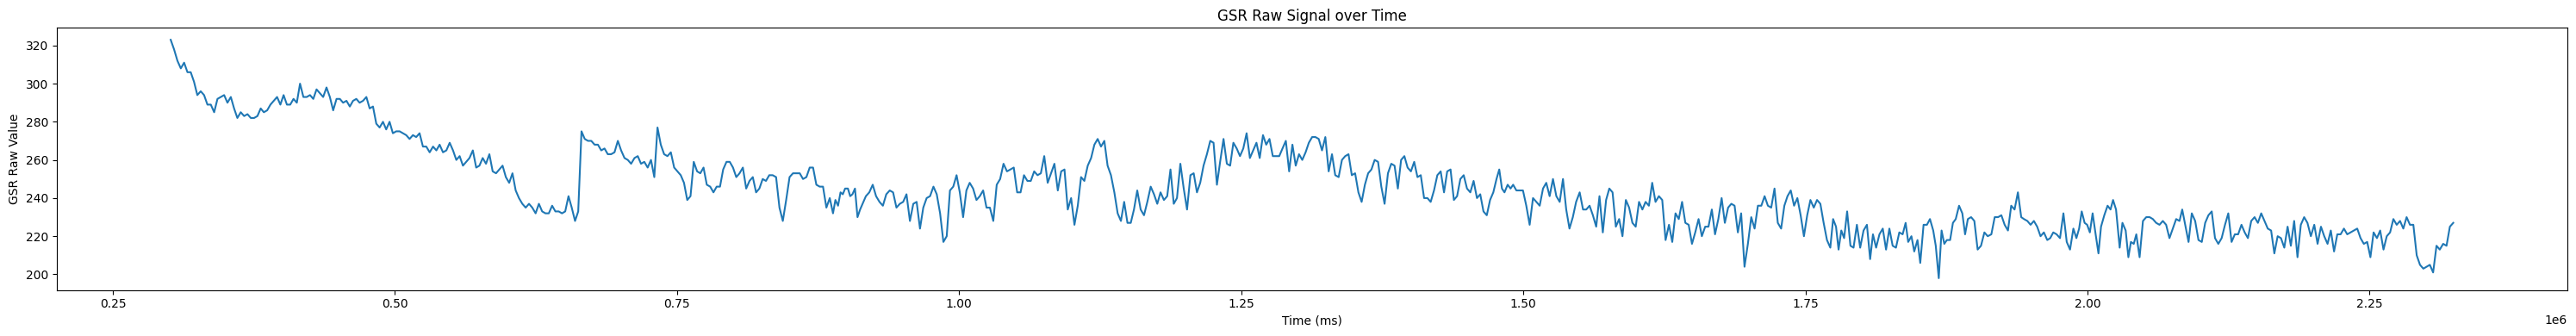

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取 CSV 文件
# 尝试使用不同的编码，例如 'gbk' 或 'latin1'
try:
    df = pd.read_csv('/content/2_gps_with_minute_time.csv', encoding='gbk')
except UnicodeDecodeError:
    df = pd.read_csv('/content/2_gps_with_minute_time.csv', encoding='latin1')

# 2. 提取 ms 和 gsr
x = df['ms']
y = df['gsr_raw'] # 确保这里是正确的列名，如果不是，请告诉我

# 3. 绘制折线图
plt.figure(figsize=(30, 4))
plt.plot(x, y)
plt.xlabel('Time (ms)')
plt.ylabel('GSR Raw Value') # 更改Y轴标签以更准确地描述数据
plt.title('GSR Raw Signal over Time')

# 4. 显示
plt.tight_layout()
plt.savefig('gsr-plot2.svg', format='svg') # 导出为SVG文件
plt.show()

In [ ]:
import pandas as pd

# 1. 读取原始数据
df = pd.read_csv('/content/2_gps.csv')

# 获取第一个 'ms' 值作为时间偏移量，使其从相对0开始
first_ms = df['ms'].iloc[0]

# 2. ms → “xx分xx秒”
def ms_to_min_sec(ms_value):
    # 使用相对毫秒值进行计算
    total_seconds = int(ms_value // 1000)
    minutes = total_seconds // 60
    seconds = total_seconds % 60
    return f"{minutes}分{seconds}秒"

# 3. 在第一列插入时间列，使用相对时间进行转换
df.insert(0, 'time_min_sec', (df['ms'] - first_ms).apply(ms_to_min_sec))

# 4. 导出新的 CSV
df.to_csv('2_gps_with_minute_time.csv', index=False)

print("已生成文件：3_gps_with_minute_time.csv")

已生成文件：3_gps_with_minute_time.csv


    time_min_sec  gsr_raw
0           4分6秒      400
1           4分9秒      409
2          4分12秒      401
3          4分15秒      397
4          4分18秒      397
..           ...      ...
853       44分46秒      367
854       44分49秒      370
855       44分51秒      369
856       44分54秒      368
857       44分57秒      369

[858 rows x 2 columns]


/tmp/ipython-input-3516000463.py:18: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.savefig("gsr_raw.svg", format="svg")
/tmp/ipython-input-3516000463.py:18: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  plt.savefig("gsr_raw.svg", format="svg")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 31186 (\N{CJK UNIFIED IDEOGRAPH-79D2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


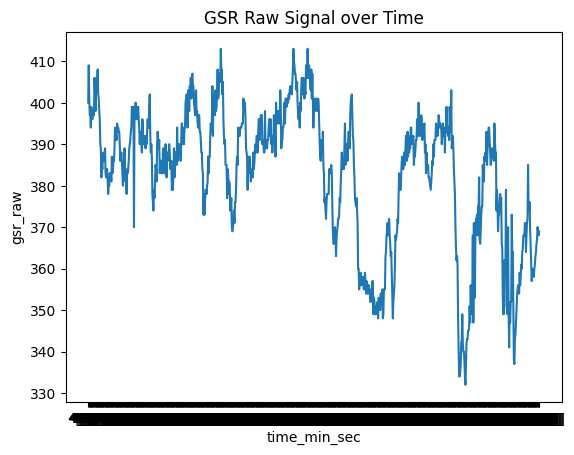

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取包含 'time_min_sec' 的 CSV 文件
df = pd.read_csv('/content/3_gps_with_minute_time.csv')

# 2. 打印 CSV (仅打印相关列以便查看)
print(df[['time_min_sec', 'gsr_raw']])

# 3. 绘制折线图
plt.figure()
plt.plot(df["time_min_sec"], df["gsr_raw"])
plt.xlabel("time_min_sec")
plt.ylabel("gsr_raw")
plt.title("GSR Raw Signal over Time")

# 4. 导出为 SVG
plt.savefig("gsr_raw.svg", format="svg")

# 5. 显示图像
plt.show()